[2, 4, 6, 8] [81, 93, 91, 97]


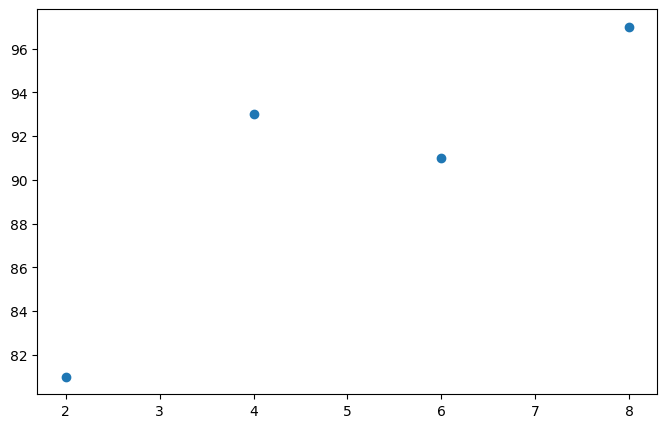

In [ ]:
# 오차(loss)와 기울기(weight),절편(bias)
# 경사하강법 적용 코드

# 공부시간(x축)r과 점수(y축)간의 그래프 작성
# uv add matplotlib
# matplotlib: 파이썬 시각화 라이브러리

import numpy as np
import matplotlib.pyplot as plt
#matplotlib라이브러리 내부에 있는 서브 모듈 파이 플롯
# 그래프 그리는 모듈 

#공부 시간 x와 성적 y의 리스트를 만들기
#2차원 리스트 [공부시간, 점수]형태
data = [[2,81],[4,93],[6,91],[8,97]]
#2시간 공부 시 81점, 4시간 공부 시 93점 ,...
#공부시간(입력)이 x, 점수가 정답(label,출력) y

x = [i[0] for i in data]#[2,4,6,8]
y = [i[1] for i in data]#[82,93,91,97]

#x,y data 확인
print(x,y)#[2,4,6,8] [82,93,91,97]

#그래프로 나타내기
plt.figure(figsize=(8,5))#그래프 캔버스 생성
#크기 : 가로 8인치 * 세로 5인치
plt.scatter(x,y)# 좌표평면에 점 찍기
#x축: 공부시간, y축: 점수
plt.show()# 그래프 실제 출력(렌더링)



epoch=0, 기울기=46.4000, 절편=9.0500
epoch=100, 기울기=2418478117062402073952133996085248.0000, 절편=405270013216241424840325620301824.0000
epoch=200, 기울기=185719364669233752219629566456254005543684898338709890459244691456.0000, 절편=31121426670353590752218299939770683531479248570440853702934790144.0000
epoch=300, 기울기=14261730205373602513874542029949442679016613603068807701329004847279875738058516589811801222283264.0000, 절편=2389871360853456434489730078568588285448055643469487934952246020631114094776416180349975929028608.0000
epoch=400, 기울기=1095184386469960806303898659279930350408605934250761120486105224484330042950118847408930491069390991042329920491364212239583150080.0000, 절편=183522599459373251461817843978972193007154501343978823689289837966162958770239198437316527548930328309216467586604723234154741760.0000
epoch=500, 기울기=84101215146788670008210403617984337965697431748615875899186257234594377506423721117737161181176225703762004748280914070263250674478115873601798478610706315870208.0000, 절편=140930

C:\Users\user\AppData\Local\Temp\ipykernel_15692\3758525898.py:33: RuntimeWarning: overflow encountered in scalar add
  a_diff = 2/len(x_data) * sum((a * x_data + b - y_data) * x_data)
C:\Users\user\AppData\Local\Temp\ipykernel_15692\3758525898.py:38: RuntimeWarning: invalid value encountered in scalar subtract
  a = a -lr * a_diff # a값 업데이트


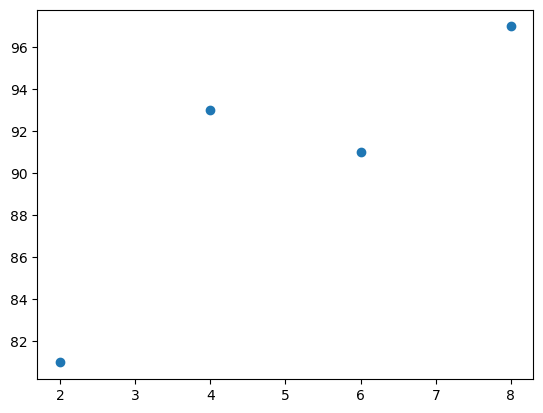

In [5]:
# 목표: x,y관계를 가장 잘 설명하는 직선 찾기
# 그 선을 기준으로 새로운 데이터(x)가 들어왔을 때 y값을 예측함
# y = ax+b에서 a,b 최적값을 찾아보자

##리스트로 되어있는 x와 y값을 넘파이 배열로 바꾸기
#numpy 배열 변환 - 백터 계산 가능
x_data = np.array(x)
y_data = np.array(y)

#기울기 a와 절편 b의 값 초기화
# y = 0x + 0으로 시작한다는 뜻
a = 0
b = 0

#learning rate 학습률 
#한 번 업데이트할 때마다 얼마나 이동할 것인가
#너무 크면 최적점 지나쳐서 발산 우려, 너무 작으면 학습 오래걸림
#딥러닝 모델에서 학습전 사람이 설정하는 하이퍼파라미터 중 하나
lr = 0.05

#몇 번 반복될지 설정
#0부터 세므로 원하는 반복횟수에 +1
epochs = 2001#전체 데이터 반복 학습 횟수
#0~2000까지 총 2001번
#많을 수록 더 오래 학습하지만, 
# 과적합(overfitting) 주의 - 노이즈, 튀는 데이터까지 과하게 학습해서
# 예측율 오히려 떨어짐

for i in range(epochs): #반복학습 시작 : 반복하며 a,b 파라미터 업데이트
    #반복 최적화 
    #가중치와 손실의 관계에서 현재 위치의 기울기를 구하기 위해 미분
    #현재 weight 위치에서의 loss 변화율 
    a_diff = 2/len(x_data) * sum((a * x_data + b - y_data) * x_data)
    #편향과 손실의 관계에서 현재 위치의 기울기를 구하기 위해 미분
    #현재 bias 위치에서의 loss 변화율
    b_diff = 2/len(x_data) * sum(a * x_data + b - y_data)
    #경사하강법
    a = a -lr * a_diff # a값 업데이트
    b = b -lr * b_diff # b값 업데이트
    if i % 100 == 0: #100번 반복할 때마다 현재의 a값, b값 출력
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f" % (i,a,b))

# 구한 기울기와 절편을 이용해 그래프 그림
y_pred = a * x_data + b #예측값
plt.scatter(x,y)
plt.plot(x_data, y_pred)
plt.show()

#(a * x_data + b - y_data)에서
#a * x_data + b 이게 예측값이고
#y_data 이게 실제값
#즉 예측값 - 실제값 = 오차에다가  * x_data를 곱함
# x^2을 미분하면 지수에 있던 숫자 2가 앞으로 뚝 떨어지면서 곱해지고
# 원래있던 제곱은 차수가 줄어듬 x^1
# x^2미분 -> 2x가 됨

# (ax+b-y)^2 즉 (예측값 - 실제값)의 제곱을 a대해 미분
# 1단계: 겉미분하면
# 2(ax+b-y)가 됨
# 2단계: 속미분
# (ax+b-y)를 a를 기준으로 미분
# ax를 a를 기준으로 미분 -> x
# b는 상수라서 0, y도 상수 0
# 그래서 x만 남음
# 최종 결과 : 겉미분 * 속미분
# 2(ax+b-y)x 가됨
# 그래서 코드가 (a * x_data + b - y_data) * x_data이렇게 나오는 것
# 앞에 2는 2/len(x_data) 여기에 붙음
# gradient는 손실함수를 가중치에 대해 미분한값
# 손실함수를 편향에 대해 미분한 값

#목표: 오차(loss)를 최소화 하는 a,b를 찾는것
# 그래서 현재 a,b상태에서 a,b를 어느방향(증가할지, 감소시킬지)으로 이동할지 알아야한다
# 그래서 계산하는게 바로 gradient
# 가중치/편향 각각을 기준으로 loss를 미분한값이 gradient
# a를 바꾸었을때 loss가 얼마나 변하는지, b를 바꾸었을 때 loss가 얼마나 변하는지
# 미분은 본질적으로 변화율
# 간단하게 loss와 가중치, loss와 bias의 관계를 각각 
# 2차함수로 표현하면 U  (가중치 딱 1와 오차와의 관계에서는 2차함수)
# (가중치, 편향이 더 추가되면 복잡해짐, 울퉁불퉁모자, 말안장 같은 복잡한 그래프)
# 개념을 간단하게 이해하기 위해 2차함수로 예시를 들면
# 그 그래프 상에서 gradient가 양수일때 
# 가중치가 증가하면 오차 증가 -> 가중치는 감소 하는 방향으로 움직여야함
# gradient가 음수일 때 가중치가 증가하면 오차 감소
# -> 가중치 증가시키는 방향으로 움직여야함
# 새가중치 = 기존가중치 - 러닝레이트 * gradient
# 선형 회귀에서는 손실 계산식 MSE를 미분한게 gradient
# 즉 코드에서 a_diff에 해당하는 값
# -> MSE를 가중치에 대해 미분한 값 -> gradient
# gradient는 loss 함수의 변화율
# weight를 바꿀 때 loss가 얼마나 변하는지 나타낸다.
# 경사하강법은 오차가 가장 낮은 지점까지 이동하는 것

#예측값(y_pred)과 실제값(y_data) 차이 즉 오차를 줄이고 싶음
# 오차가 줄어드는 방향으로 a,b를 조금씩 수정 -> 반복학습
# 예측값 계산 y_pred = a * x_data + b
# 현재 기울기 a와 절편 b로 예측 직선 만듬

# a_diff = 2/len(x_data) * sum((a * x_data + b - y_data) * x_data)
# 이건 현재 기울기 a를 어느 방향으로 얼마나 수정해야하는가를 계산하는 식
# a_diff는 a 방향의 gradient

#b_diff = 2/len(x_data) * sum(a * x_data + b - y_data)
# 절편 b를 어느 방향으로 수정해야 하는가
# 절편 b는 직선 위아래로 이동, x의 영향과 관계가 없음


#MSE가 왜 제곱을 쓰는가
#오차를 제곱하는 이유는
#양수/음수 오차를 모두 양수로 만들고,
#큰 오차에 더 큰 패널티를 주기 위함이다.


입력 데이터: [2, 4, 6, 8] [81, 93, 91, 97]


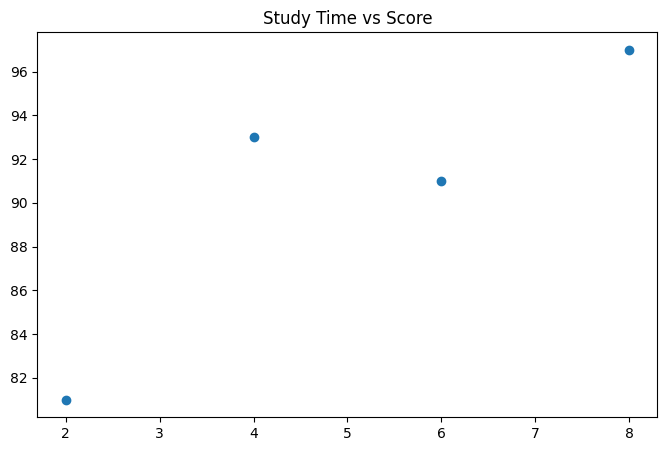

epoch=   0, 기울기=27.8400, 절편=5.4300
epoch= 100, 기울기=7.0739, 절편=50.5117
epoch= 200, 기울기=4.0960, 절편=68.2822
epoch= 300, 기울기=2.9757, 절편=74.9678
epoch= 400, 기울기=2.5542, 절편=77.4830
epoch= 500, 기울기=2.3956, 절편=78.4293
epoch= 600, 기울기=2.3360, 절편=78.7853
epoch= 700, 기울기=2.3135, 절편=78.9192
epoch= 800, 기울기=2.3051, 절편=78.9696
epoch= 900, 기울기=2.3019, 절편=78.9886
epoch=1000, 기울기=2.3007, 절편=78.9957
epoch=1100, 기울기=2.3003, 절편=78.9984
epoch=1200, 기울기=2.3001, 절편=78.9994
epoch=1300, 기울기=2.3000, 절편=78.9998
epoch=1400, 기울기=2.3000, 절편=78.9999
epoch=1500, 기울기=2.3000, 절편=79.0000
epoch=1600, 기울기=2.3000, 절편=79.0000
epoch=1700, 기울기=2.3000, 절편=79.0000
epoch=1800, 기울기=2.3000, 절편=79.0000
epoch=1900, 기울기=2.3000, 절편=79.0000
epoch=2000, 기울기=2.3000, 절편=79.0000


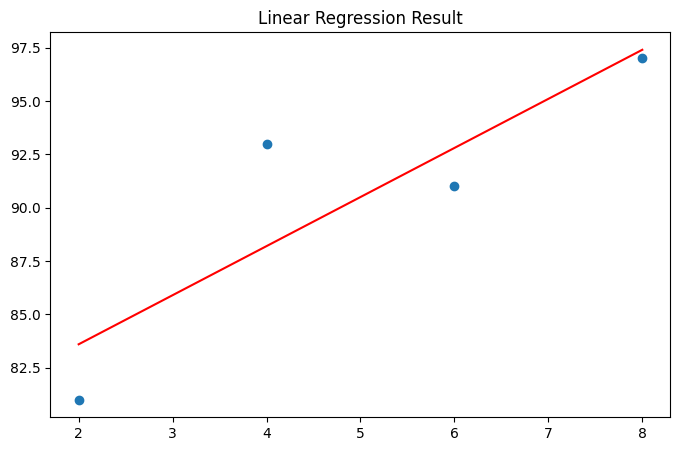

In [6]:
# epoch=1000, 기울기=nan, 절편=nan
# 발산하는 이유??
# learning rate를 크게 주어서,,
#안정적인 수렴을 위해 학습률을 줄여보자

import numpy as np 
import matplotlib.pyplot as plt 

# 공부 시간 x와 성적 y의 리스트를 만들기 
data = [[2, 81], [4, 93], [6, 91], [8, 97]]
x = [i[0] for i in data]
y = [i[1] for i in data]

# x, y data 확인
print("입력 데이터:", x, y)

# 그래프로 나타내기 
plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.title("Study Time vs Score")
plt.show()

# 리스트로 되어있는 x와 y값을 넘파이 배열로 바꾸기
x_data = np.array(x)
y_data = np.array(y)

# 기울기 a와 절편 b의 값 초기화 
a = 0
b = 0

# 학습률 정하기 
lr = 0.03 # 안정적인 수렴을 위해 학습률을 0.05에서 0.03으로 살짝 조정했습니다.

# 반복 횟수 설정
epochs = 2001

# 경사 하강법 시작 
for i in range(epochs): 
    # 오차함수를 a로 미분한 값
    a_diff = (2/len(x_data)) * sum((a * x_data + b - y_data) * x_data) 
    # 오차함수를 b로 미분한 값
    b_diff = (2/len(x_data)) * sum(a * x_data + b - y_data) 
    
    a = a - lr * a_diff # 기울기 업데이트
    b = b - lr * b_diff # 절편 업데이트
    
    if i % 100 == 0: 
        print(f"epoch={i:4d}, 기울기={a:.4f}, 절편={b:.4f}")

# 앞서 구한 기울기와 절편을 이용해 그래프를 다시 그리기 
y_pred = a * x_data + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x_data, y_pred, 'r') # 회귀선을 빨간색(r)으로 표시
plt.title("Linear Regression Result")
plt.show()